# IR 경진대회 EDA

**목적**: 문서 및 평가 쿼리 데이터의 특성을 파악하여 Indexing / Retrieval / Generation 실험 전략 수립

- `documents.jsonl`: 색인 대상 과학 상식 문서 (~4,200개)
- `eval.jsonl`: 평가 쿼리 (220개)

In [29]:
import json
import platform
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows: Malgun Gothic / Colab·Linux: NanumGothic)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print(f"OS: {platform.system()}")
print(f"font.family: {plt.rcParams['font.family']}")
print("라이브러리 로딩 완료")

OS: Linux
font.family: ['NanumGothic']
라이브러리 로딩 완료


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# 데이터 로딩
docs = []
with open('/content/drive/My Drive/Colab Notebooks/documents.jsonl', encoding='utf-8') as f:
    for line in f:
        docs.append(json.loads(line))

evals = []
with open('/content/drive/My Drive/Colab Notebooks/eval.jsonl', encoding='utf-8') as f:
    for line in f:
        evals.append(json.loads(line))

docs_df = pd.DataFrame(docs)
evals_df = pd.DataFrame(evals)

print(f"문서 수: {len(docs_df)}")
print(f"평가 쿼리 수: {len(evals_df)}")
print()
print("=== documents 컬럼 ===")
print(docs_df.dtypes)
print()
print("=== 문서 샘플 ===")
docs_df.head(3)

문서 수: 4272
평가 쿼리 수: 220

=== documents 컬럼 ===
docid      object
src        object
content    object
dtype: object

=== 문서 샘플 ===


,docid,src,content
0,42508ee0-c543-4338-878e-d98c6babee66,ko_mmlu__nutrition__test,건강한 사람이 에너지 균형을 평형 상태로 유지하는 것은 중요합니다. 에너지 균형은 ...
1,4a437e7f-16c1-4c62-96b9-f173d44f4339,ko_mmlu__conceptual_physics__test,"수소, 산소, 질소 가스의 혼합물에서 평균 속도가 가장 빠른 분자는 수소입니다. 수..."
2,d3c68be5-9cb1-4d6e-ba18-5f81cf89affb,ko_ai2_arc__ARC_Challenge__test,종이와 플라스틱은 재활용 가능한 자원입니다. 중학교 과학 수업에서 우리는 종이와 플...


---
## 1. Documents 분석

### 1-1. 출처(src) 분포

In [32]:
# 출처 유형 파싱
docs_df['source_type'] = docs_df['src'].apply(lambda x: 'ko_mmlu' if 'mmlu' in x else 'ko_ai2_arc')
docs_df['split'] = docs_df['src'].apply(lambda x: x.split('__')[-1])  # test / train / validation
docs_df['category'] = docs_df['src'].apply(
    lambda x: x.split('__')[1] if 'mmlu' in x else 'ARC_Challenge'
)

print("=== 소스 유형 분포 ===")
print(docs_df['source_type'].value_counts())
print()
print("=== 데이터 split 분포 ===")
print(docs_df['split'].value_counts())

=== 소스 유형 분포 ===
source_type
ko_mmlu       2225
ko_ai2_arc    2047
Name: count, dtype: int64

=== 데이터 split 분포 ===
split
test          2913
train          925
validation     434
Name: count, dtype: int64


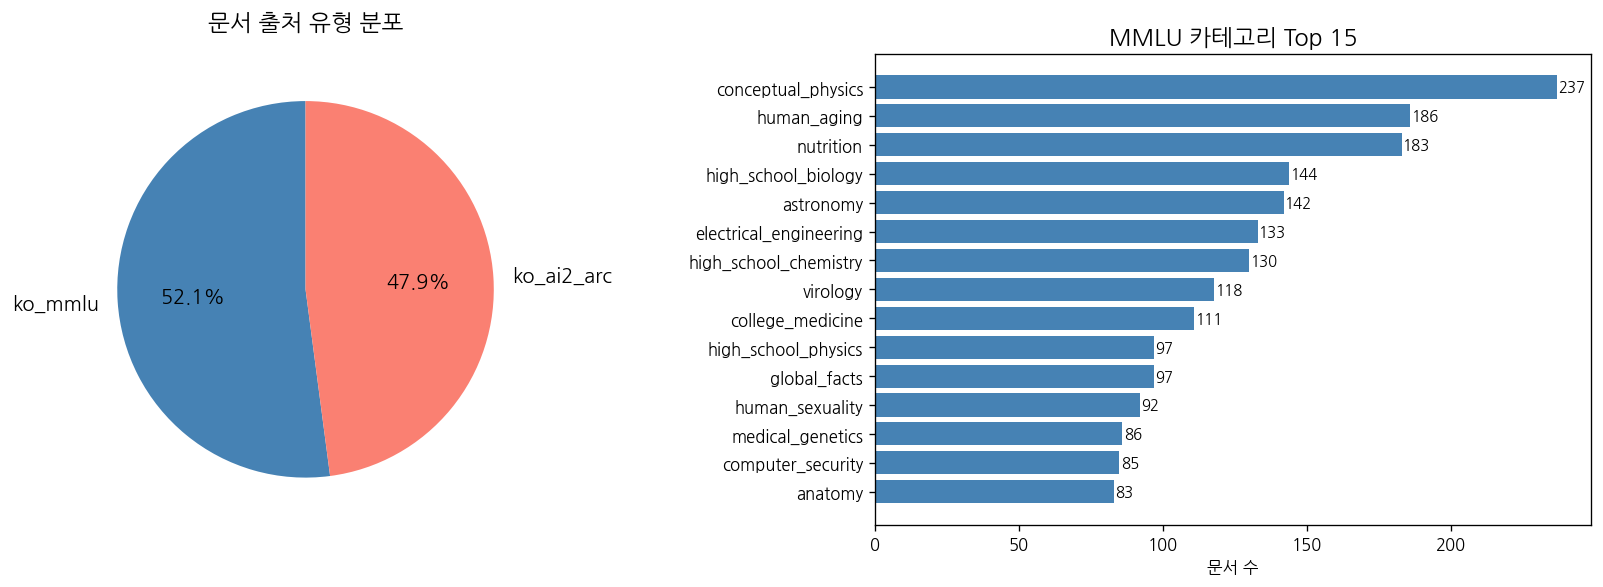

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 소스 유형 파이차트
source_counts = docs_df['source_type'].value_counts()
axes[0].pie(source_counts, labels=source_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('문서 출처 유형 분포', fontsize=14, pad=15)

# MMLU 카테고리 Top 15 (ko_ai2_arc 제외)
mmlu_cats = docs_df[docs_df['source_type'] == 'ko_mmlu']['category'].value_counts().head(15)
bars = axes[1].barh(mmlu_cats.index[::-1], mmlu_cats.values[::-1], color='steelblue')
axes[1].set_title('MMLU 카테고리 Top 15', fontsize=14)
axes[1].set_xlabel('문서 수')
for bar, val in zip(bars, mmlu_cats.values[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/eda_01_source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1-2. 문서 길이 분포
> **청킹 전략 수립의 핵심 근거**

In [34]:
# 문서 길이 계산 (글자 수, 단어 수, 추정 토큰 수)
docs_df['char_len'] = docs_df['content'].apply(len)
docs_df['word_len'] = docs_df['content'].apply(lambda x: len(x.split()))
# 한국어 토큰 추정: 형태소 분석 없이 글자수 기반 (글자수 / 1.5 ≈ 서브워드 토큰)
docs_df['token_est'] = (docs_df['char_len'] / 1.5).astype(int)

print("=== 문서 길이 통계 ===")
stats = docs_df[['char_len', 'word_len', 'token_est']].describe().round(1)
stats.columns = ['글자 수', '단어 수', '추정 토큰 수']
print(stats)
print()

# 토큰 구간별 분포
bins = [0, 100, 200, 300, 400, 500, float('inf')]
labels = ['~100', '101~200', '201~300', '301~400', '401~500', '500+']
docs_df['token_bin'] = pd.cut(docs_df['token_est'], bins=bins, labels=labels)
print("=== 추정 토큰 구간별 문서 수 ===")
bin_counts = docs_df['token_bin'].value_counts().sort_index()
for label, count in bin_counts.items():
    print(f"  {label:>10} tokens : {count:>5}개 ({count/len(docs_df)*100:.1f}%)")

=== 문서 길이 통계 ===
         글자 수    단어 수  추정 토큰 수
count  4272.0  4272.0   4272.0
mean    315.3    74.7    209.9
std     104.0    25.0     69.3
min      44.0     9.0     29.0
25%     251.0    59.0    167.0
50%     299.0    71.0    199.0
75%     357.0    85.0    238.0
max    1230.0   315.0    820.0

=== 추정 토큰 구간별 문서 수 ===
        ~100 tokens :    57개 (1.3%)
     101~200 tokens :  2130개 (49.9%)
     201~300 tokens :  1771개 (41.5%)
     301~400 tokens :   225개 (5.3%)
     401~500 tokens :    59개 (1.4%)
        500+ tokens :    30개 (0.7%)


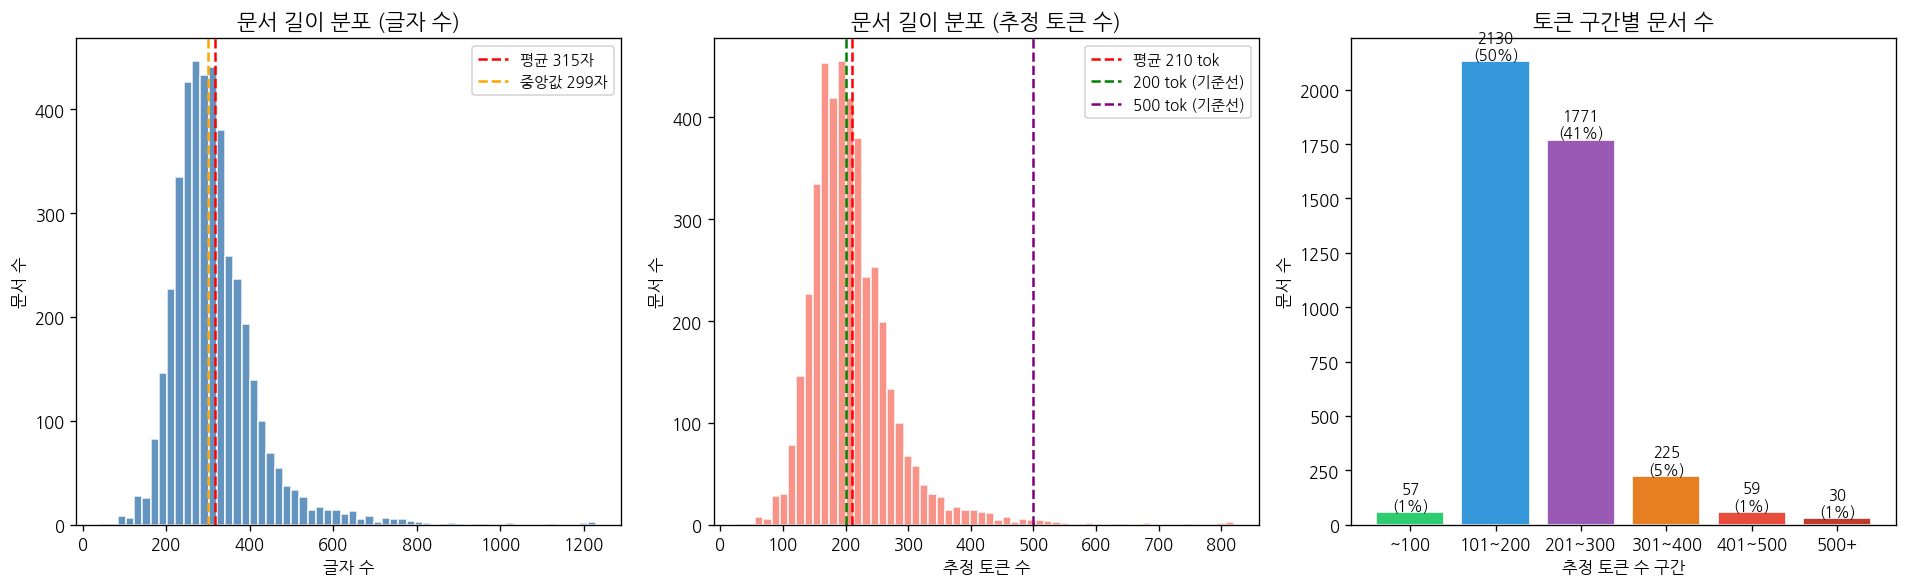

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) 글자 수 히스토그램
axes[0].hist(docs_df['char_len'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(docs_df['char_len'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'평균 {docs_df["char_len"].mean():.0f}자')
axes[0].axvline(docs_df['char_len'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'중앙값 {docs_df["char_len"].median():.0f}자')
axes[0].set_title('문서 길이 분포 (글자 수)', fontsize=13)
axes[0].set_xlabel('글자 수')
axes[0].set_ylabel('문서 수')
axes[0].legend(fontsize=9)

# 2) 추정 토큰 수 히스토그램
axes[1].hist(docs_df['token_est'], bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[1].axvline(docs_df['token_est'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'평균 {docs_df["token_est"].mean():.0f} tok')
axes[1].axvline(200, color='green', linestyle='--', linewidth=1.5, label='200 tok (기준선)')
axes[1].axvline(500, color='purple', linestyle='--', linewidth=1.5, label='500 tok (기준선)')
axes[1].set_title('문서 길이 분포 (추정 토큰 수)', fontsize=13)
axes[1].set_xlabel('추정 토큰 수')
axes[1].set_ylabel('문서 수')
axes[1].legend(fontsize=9)

# 3) 토큰 구간별 바차트
bin_counts = docs_df['token_bin'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c', '#c0392b']
bars = axes[2].bar(bin_counts.index, bin_counts.values, color=colors, edgecolor='white')
axes[2].set_title('토큰 구간별 문서 수', fontsize=13)
axes[2].set_xlabel('추정 토큰 수 구간')
axes[2].set_ylabel('문서 수')
for bar, val in zip(bars, bin_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}\n({val/len(docs_df)*100:.0f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/eda_02_doc_length.png', dpi=150, bbox_inches='tight')
plt.show()

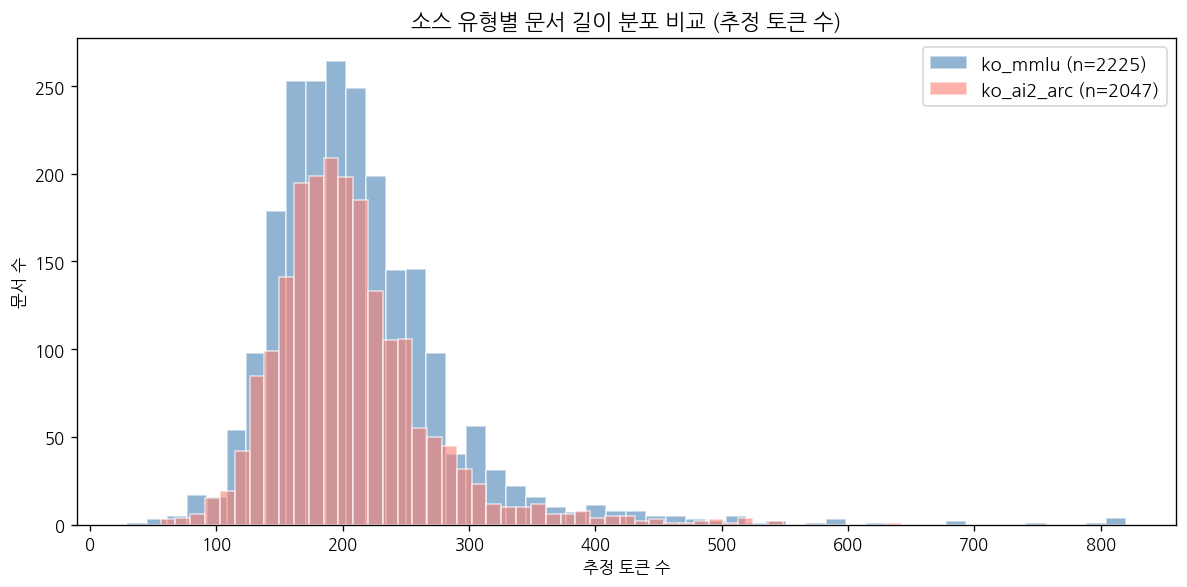

소스 유형별 평균 토큰 수:
              count   mean   std   min    25%    50%    75%    max
source_type                                                       
ko_ai2_arc   2047.0  206.2  61.7  56.0  167.0  197.0  232.0  642.0
ko_mmlu      2225.0  213.3  75.5  29.0  166.0  202.0  244.0  820.0


In [36]:
# 소스 유형별 문서 길이 비교
fig, ax = plt.subplots(figsize=(10, 5))

for src_type, color in zip(['ko_mmlu', 'ko_ai2_arc'], ['steelblue', 'salmon']):
    subset = docs_df[docs_df['source_type'] == src_type]['token_est']
    ax.hist(subset, bins=50, alpha=0.6, label=f'{src_type} (n={len(subset)})', color=color, edgecolor='white')

ax.set_title('소스 유형별 문서 길이 분포 비교 (추정 토큰 수)', fontsize=13)
ax.set_xlabel('추정 토큰 수')
ax.set_ylabel('문서 수')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('/eda_03_length_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

print("소스 유형별 평균 토큰 수:")
print(docs_df.groupby('source_type')['token_est'].describe().round(1))

---
## 2. Eval 쿼리 분석

### 2-1. 턴 수 분포 (단일턴 vs 멀티턴)

In [37]:
# 멀티턴 분석
evals_df['num_turns'] = evals_df['msg'].apply(len)
evals_df['is_multiturn'] = evals_df['num_turns'] > 1
evals_df['last_query'] = evals_df['msg'].apply(lambda x: x[-1]['content'])
evals_df['first_query'] = evals_df['msg'].apply(lambda x: x[0]['content'])
evals_df['query_len'] = evals_df['last_query'].apply(len)

print("=== 턴 수 분포 ===")
turn_dist = evals_df['num_turns'].value_counts().sort_index()
for turns, count in turn_dist.items():
    label = '단일턴' if turns == 1 else f'{turns}턴 멀티턴'
    print(f"  {label}: {count}개 ({count/len(evals_df)*100:.1f}%)")

print()
print("=== 멀티턴 샘플 (standalone query 추출 난이도 확인) ===")
multiturn_samples = evals_df[evals_df['is_multiturn']].head(3)
for _, row in multiturn_samples.iterrows():
    print(f"\n[eval_id {row['eval_id']}]")
    for turn in row['msg']:
        role = '사용자' if turn['role'] == 'user' else '어시스턴트'
        print(f"  {role}: {turn['content']}")

=== 턴 수 분포 ===
  단일턴: 200개 (90.9%)
  3턴 멀티턴: 20개 (9.1%)

=== 멀티턴 샘플 (standalone query 추출 난이도 확인) ===

[eval_id 107]
  사용자: 기억 상실증 걸리면 너무 무섭겠다.
  어시스턴트: 네 맞습니다.
  사용자: 어떤 원인 때문에 발생하는지 궁금해.

[eval_id 42]
  사용자: 이란 콘트라 사건이 뭐야
  어시스턴트: 이란-콘트라 사건은 로널드 레이건 집권기인 1986년에 레이건 행정부와 CIA가 적성국이었던 이란에게 무기를 몰래 수출한 대금으로 니카라과의 우익 성향 반군 콘트라를 지원하면서 동시에 반군으로부터 마약을 사들인 후 미국에 판매하다가 발각되어 큰 파장을 일으킨 사건입니다.
  사용자: 이 사건이 미국 정치에 미친 영향은?

[eval_id 43]
  사용자: 달을 보면 항상 같은 면만 보이더라구
  어시스턴트: 네 맞습니다.
  사용자: 그 이유가 뭐야?


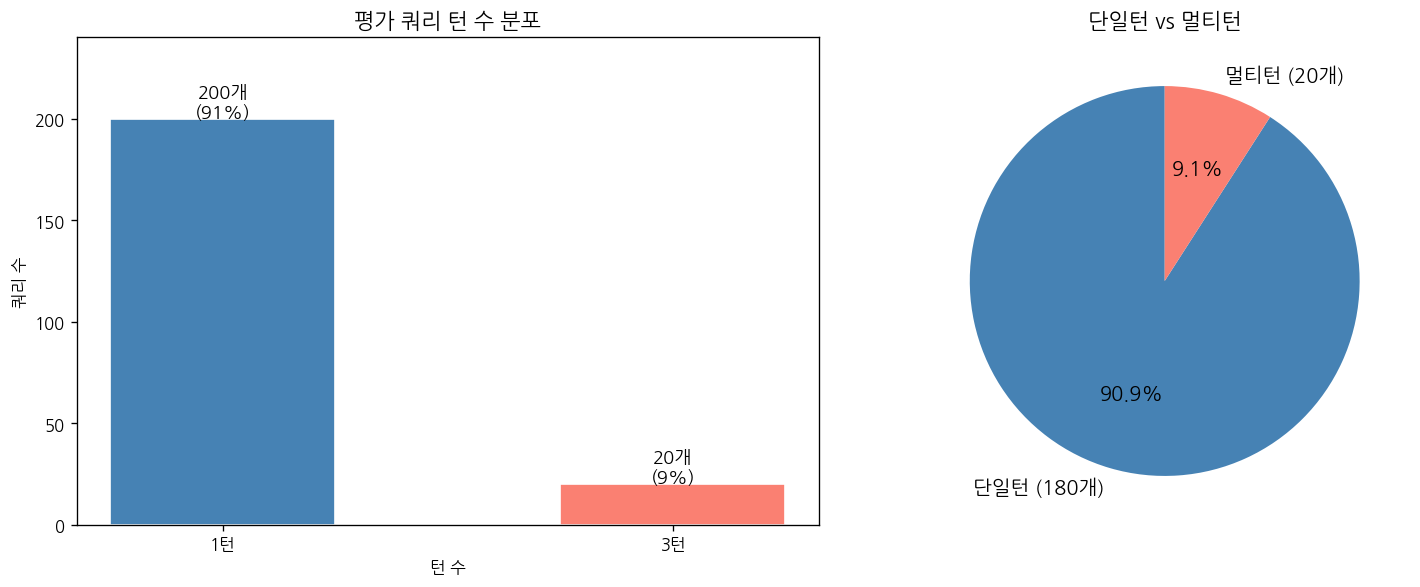

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 턴 수 분포 바차트
turn_counts = evals_df['num_turns'].value_counts().sort_index()
bar_colors = ['steelblue', 'salmon', 'gold'][:len(turn_counts)]
bars = axes[0].bar([f'{t}턴' for t in turn_counts.index], turn_counts.values,
                    color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('평가 쿼리 턴 수 분포', fontsize=13)
axes[0].set_xlabel('턴 수')
axes[0].set_ylabel('쿼리 수')
for bar, val in zip(bars, turn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}개\n({val/len(evals_df)*100:.0f}%)', ha='center', fontsize=11)
axes[0].set_ylim(0, max(turn_counts.values) * 1.2)

# 단일/멀티 파이차트
labels = ['단일턴 (180개)', '멀티턴 (20개)']
sizes = [evals_df['num_turns'].eq(1).sum(), evals_df['is_multiturn'].sum()]
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('단일턴 vs 멀티턴', fontsize=13)

plt.tight_layout()
plt.savefig('/eda_04_turn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2-2. 쿼리 길이 분포 및 문서와의 비교
> **Sparse vs Dense 검색 전략 선택의 근거**

In [39]:
print("=== 쿼리 길이 통계 (마지막 user 메시지 기준) ===")
print(evals_df['query_len'].describe().round(1))
print()
print(f"문서 평균 길이: {docs_df['char_len'].mean():.0f}자")
print(f"쿼리 평균 길이: {evals_df['query_len'].mean():.0f}자")
print(f"길이 비율: 문서가 쿼리보다 평균 {docs_df['char_len'].mean() / evals_df['query_len'].mean():.1f}배 김")
print()
print("=== 쿼리 길이 구간별 ===")
q_bins = [0, 10, 20, 30, 40, float('inf')]
q_labels = ['~10자', '11~20자', '21~30자', '31~40자', '40자+']
evals_df['query_len_bin'] = pd.cut(evals_df['query_len'], bins=q_bins, labels=q_labels)
for label, count in evals_df['query_len_bin'].value_counts().sort_index().items():
    print(f"  {label}: {count}개")

=== 쿼리 길이 통계 (마지막 user 메시지 기준) ===
count    220.0
mean      24.3
std        9.4
min        6.0
25%       18.0
50%       24.0
75%       29.0
max       70.0
Name: query_len, dtype: float64

문서 평균 길이: 315자
쿼리 평균 길이: 24자
길이 비율: 문서가 쿼리보다 평균 13.0배 김

=== 쿼리 길이 구간별 ===
  ~10자: 13개
  11~20자: 62개
  21~30자: 98개
  31~40자: 35개
  40자+: 12개


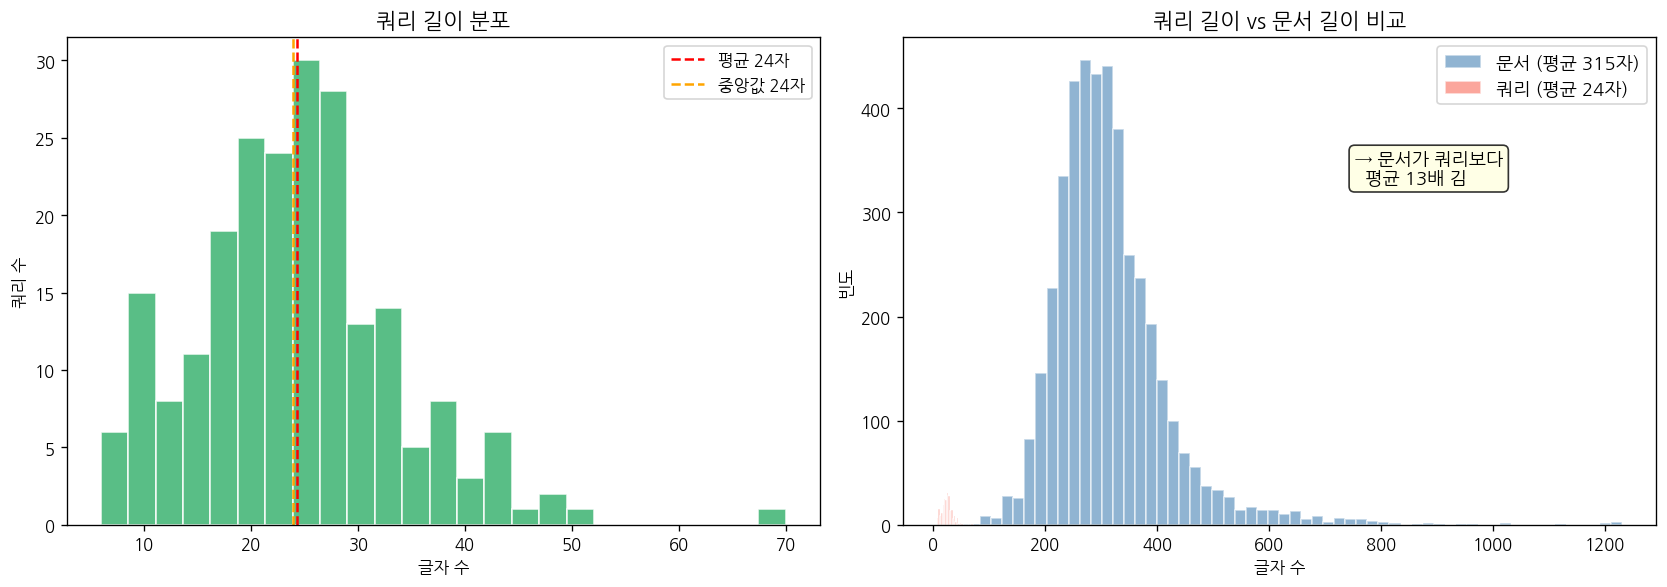

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 쿼리 길이 히스토그램
axes[0].hist(evals_df['query_len'], bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(evals_df['query_len'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'평균 {evals_df["query_len"].mean():.0f}자')
axes[0].axvline(evals_df['query_len'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'중앙값 {evals_df["query_len"].median():.0f}자')
axes[0].set_title('쿼리 길이 분포', fontsize=13)
axes[0].set_xlabel('글자 수')
axes[0].set_ylabel('쿼리 수')
axes[0].legend()

# 쿼리 vs 문서 길이 비교 (로그 스케일)
axes[1].hist(docs_df['char_len'], bins=60, alpha=0.6, label=f'문서 (평균 {docs_df["char_len"].mean():.0f}자)',
             color='steelblue', edgecolor='white')
axes[1].hist(evals_df['query_len'], bins=25, alpha=0.7, label=f'쿼리 (평균 {evals_df["query_len"].mean():.0f}자)',
             color='salmon', edgecolor='white')
axes[1].set_title('쿼리 길이 vs 문서 길이 비교', fontsize=13)
axes[1].set_xlabel('글자 수')
axes[1].set_ylabel('빈도')
axes[1].legend(fontsize=11)
axes[1].annotate(f'→ 문서가 쿼리보다\n  평균 {docs_df["char_len"].mean()/evals_df["query_len"].mean():.0f}배 김',
                 xy=(0.6, 0.7), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('/eda_05_query_length.png', dpi=150, bbox_inches='tight')
plt.show()

### 2-3. 의도 분류 난이도 분석 (일반 대화 vs 과학 질문)
> **intent 프롬프트 설계의 근거**

In [41]:
# 일반 대화 키워드 패턴으로 후보 추출 (수동 레이블링 참고용)
non_science_keywords = ['힘들', '신나', '반갑', '모르는', '대답', '잘해', '고마', '감사', '재밌',
                        'python', 'lambda', 'class', '코드', '함수', '프로그래밍', 'catalog',
                        '버스', '공교육', '지출', '정치', '이란', '콘트라', '남녀', '정서']

def guess_non_science(text):
    text_lower = text.lower()
    return any(kw in text_lower for kw in non_science_keywords)

evals_df['likely_non_science'] = evals_df['last_query'].apply(guess_non_science)

print("=== 의도 분류 난이도 분석 ===")
print(f"전체 쿼리: {len(evals_df)}개")
print(f"명확히 과학 관련: {(~evals_df['likely_non_science']).sum()}개")
print(f"과학 외 가능성 있음 (키워드 기반): {evals_df['likely_non_science'].sum()}개")
print()
print("=== 과학 외 가능성 쿼리 샘플 ===")
for _, row in evals_df[evals_df['likely_non_science']].iterrows():
    print(f"  eval_id {row['eval_id']:>4}: {row['last_query']}")

=== 의도 분류 난이도 분석 ===
전체 쿼리: 220개
명확히 과학 관련: 203개
과학 외 가능성 있음 (키워드 기반): 17개

=== 과학 외 가능성 쿼리 샘플 ===
  eval_id  213: 각 나라에서의 공교육 지출 현황에 대해 알려줘.
  eval_id   81: 통학 버스의 가치에 대해 말해줘.
  eval_id   42: 이 사건이 미국 정치에 미친 영향은?
  eval_id  276: 요새 너무 힘들다.
  eval_id   21: 다양한 책을 catalog화 하는 코드에서 class 정의 방법 알려줘.
  eval_id  261: 니가 대답을 잘해줘서 너무 신나!
  eval_id  210: python에서 lambda 함수를 언제 사용할 수 있어?
  eval_id  233: 남녀 관계에서 정서적인 행동이 왜 중요해?
  eval_id   94: 우울한데 신나는 얘기 좀 해줘!
  eval_id   90: 안녕 반갑다
  eval_id  245: 너 모르는 것도 있니?
  eval_id   67: 니가 대답을 잘해줘서 기분이 좋아!
  eval_id   57: 우울한데 신나는 얘기 좀 해줄래?
  eval_id  258: 머클-담고르 해시 함수를 사용한 MAC 보안 취약점은?
  eval_id   64: 너 모르는 것도 있어?
  eval_id   33: list의 값중 가장 작은 값을 알려주는 함수가 뭐야?
  eval_id  103: 너 뭘 잘해?


---
## 3. 실험 전략 요약

| 구분 | EDA 관찰 | 실험 방향 |
|------|---------|---------|
| **Indexing - 청킹** | 문서가 이미 단일 주제로 완결됨. 평균 토큰 수 ~210 (92.7%가 300tok 이하) | 청킹 우선순위 낮음. 임베딩 모델 교체가 더 효과적 |
| **Indexing - 임베딩** | KR-SBERT(768d) → 한국어 성능 한계 | `bge-m3` (1024d, cosine) 교체 우선 |
| **Retrieval - 방식** | 쿼리 평균 24자 vs 문서 평균 315자 (13배 차이) | 짧은 쿼리에서 BM25 한계 → Hybrid (BM25+Dense, RRF) 필수 |
| **Retrieval - topK** | 정답 후보를 3개로 바로 맞춰야 하는 구조 | topK=5 후 reranker로 3개 추출 |
| **Generation - 의도분류** | 20개 일반 대화 외에도 코딩/감성/사회 질문 경계가 모호 (키워드 기반 17개 식별) | 프롬프트에 "자연과학 범주" 명시, 코딩·일상 대화 제외 명시 |
| **Generation - 멀티턴** | 전체 20개, 모두 3턴. 마지막 메시지만으로는 검색 불가 ("그 이유가 뭐야?") | 첫 user 메시지 컨텍스트 활용 지시 추가 |